In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Shape: {df.shape}")
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Legitimate: {(df['Class']==0).sum()}")
df.describe()

Shape: (284807, 31)

Fraud rate: 0.173%
Fraud cases: 492
Legitimate: 284315


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
# Scale 'Amount' using RobustScaler (handles outliers better)
rs = RobustScaler()
df['Amount_scaled'] = rs.fit_transform(df[['Amount']])

# Scale 'Time' — convert to hours of day (0-24 cycle)
df['Hour'] = (df['Time'] / 3600) % 24

# Create time-of-day buckets (fraud spikes at certain hours)
df['TimeOfDay'] = pd.cut(df['Hour'],
                          bins=[0,6,12,18,24],
                          labels=['Night','Morning','Afternoon','Evening'],
                          include_lowest=True)

# Amount bins for SQL analysis
df['Amount_bucket'] = pd.cut(df['Amount'],
                               bins=[0,50,100,500,1000,float('inf')],
                               labels=['0-50','50-100','100-500','500-1000','1000+'])

# Drop original Time and Amount (replaced by scaled versions)
df_processed = df.drop(['Time','Amount'], axis=1)

# Save processed data
df_processed.to_csv('../data/processed/creditcard_processed.csv', index=False)
# Save original with new features for SQL
df.to_csv('../data/processed/creditcard_with_features.csv', index=False)
print("✅ Feature engineering complete")

✅ Feature engineering complete


In [5]:
print(df.dtypes)

Time              float64
V1                float64
V2                float64
V3                float64
V4                float64
V5                float64
V6                float64
V7                float64
V8                float64
V9                float64
V10               float64
V11               float64
V12               float64
V13               float64
V14               float64
V15               float64
V16               float64
V17               float64
V18               float64
V19               float64
V20               float64
V21               float64
V22               float64
V23               float64
V24               float64
V25               float64
V26               float64
V27               float64
V28               float64
Amount            float64
Class               int64
Amount_scaled     float64
Hour              float64
TimeOfDay        category
Amount_bucket    category
dtype: object


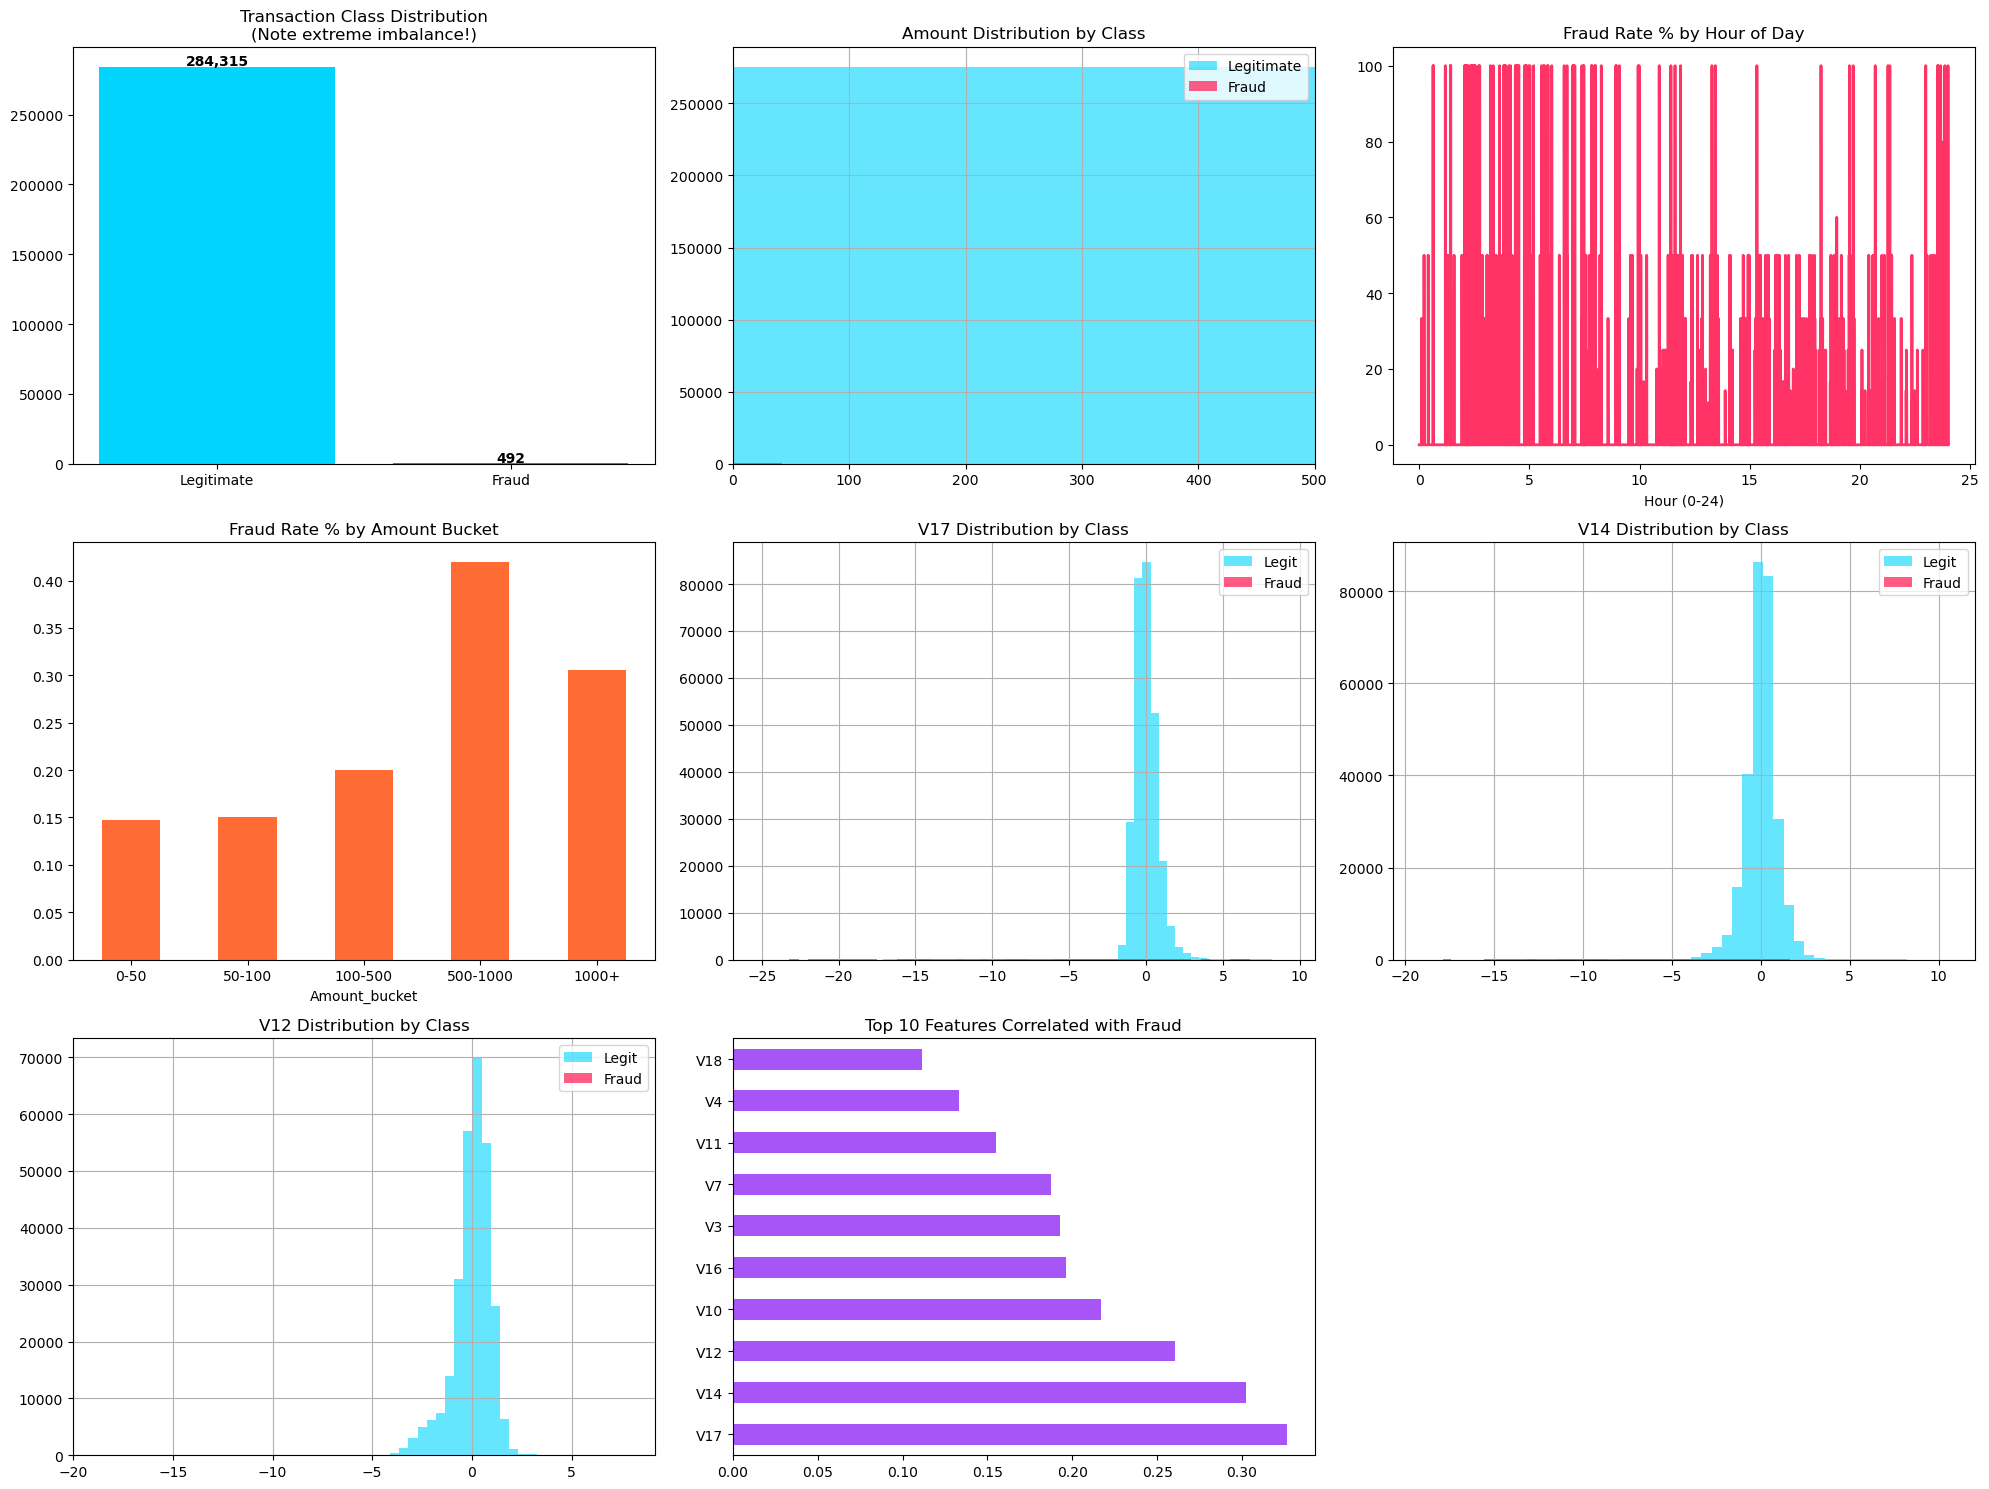

✅ EDA charts saved


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

# 1. Class Imbalance Visual (ALWAYS put this first)
class_counts = df['Class'].value_counts()
axes[0,0].bar(['Legitimate','Fraud'], class_counts.values,
               color=['#00d4ff','#ff3366'])
axes[0,0].set_title('Transaction Class Distribution\n(Note extreme imbalance!)')
for i, v in enumerate(class_counts.values):
    axes[0,0].text(i, v+1000, f'{v:,}', ha='center', fontweight='bold')

# 2. Transaction Amount Distribution by Class
df[df['Class']==0]['Amount'].hist(ax=axes[0,1], bins=50,
    alpha=0.6, color='#00d4ff', label='Legitimate')
df[df['Class']==1]['Amount'].hist(ax=axes[0,1], bins=50,
    alpha=0.8, color='#ff3366', label='Fraud')
axes[0,1].set_xlim(0,500)
axes[0,1].set_title('Amount Distribution by Class')
axes[0,1].legend()

# 3. Fraud Rate by Hour of Day
hourly = df.groupby('Hour')['Class'].mean() * 100
axes[0,2].plot(hourly.index, hourly.values, color='#ff3366', linewidth=2)
axes[0,2].fill_between(hourly.index, hourly.values, alpha=0.3, color='#ff3366')
axes[0,2].set_title('Fraud Rate % by Hour of Day')
axes[0,2].set_xlabel('Hour (0-24)')

# 4. Fraud Rate by Amount Bucket
amount_fraud = df.groupby('Amount_bucket')['Class'].mean() * 100
amount_fraud.plot(kind='bar', ax=axes[1,0], color='#ff6b35', rot=0)
axes[1,0].set_title('Fraud Rate % by Amount Bucket')

# 5-7. Top PCA features most correlated with fraud
numeric_df = df.select_dtypes(include=['number'])

corr_with_fraud = (
    numeric_df.corr()['Class']
    .abs()
    .sort_values(ascending=False)
)
top_features = corr_with_fraud.index[1:4].tolist()

for idx, feat in enumerate(top_features):
    ax = axes[1, idx+1] if idx < 2 else axes[2,0]
    df[df['Class']==0][feat].hist(ax=ax, bins=50, alpha=0.6,
                                  color='#00d4ff', label='Legit')
    df[df['Class']==1][feat].hist(ax=ax, bins=50, alpha=0.8,
                                  color='#ff3366', label='Fraud')
    ax.set_title(f'{feat} Distribution by Class')
    ax.legend()

# Feature correlation bar chart
top10_corr = corr_with_fraud[1:11]
top10_corr.plot(kind='barh', ax=axes[2,1], color='#a855f7')
axes[2,1].set_title('Top 10 Features Correlated with Fraud')

axes[2,2].axis('off')
plt.tight_layout()
plt.savefig('../reports/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved")